Script to generate snow-elevation plot (Fig. 5 in paper)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import xarray as xr
import platform
import rioxarray
import pandas as pd

if platform.system() == 'Windows':
    base_dir = Path('L:\malle\CLM5_CH')
else:
    base_dir = Path('/home/lud11/malle/CLM5_CH')
    

start by calculating hypsometry

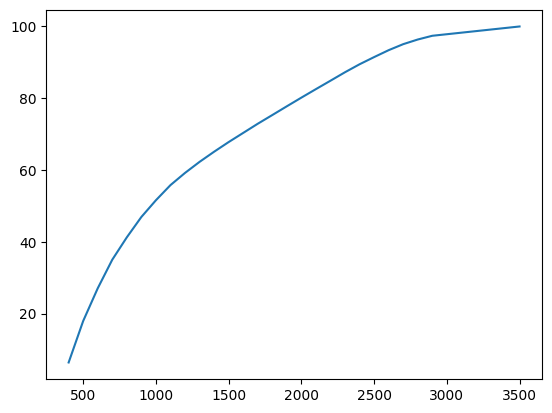

In [2]:
dem_hyp = np.hstack([150, np.arange(400, 3000, 100)])
dem_hyp_plot = np.hstack([np.arange(400, 3000, 100),3500])

dem_file = base_dir / 'BAFU_DEM_2020_1000.txt'
dem_array = rioxarray.open_rasterio(dem_file, parse_coordinates=True, masked=True)
dem_data = dem_array.squeeze()
num_all = dem_data.count().values

len_hyp = np.shape(dem_hyp)[0]
hypsom = np.zeros(len_hyp)
ids_hyp = []
for six in range(len_hyp):
    if six == len_hyp-1:
        hypsom[six] = (np.sum(dem_data > dem_hyp[six]).data / num_all) * 100
        ids_hyp.append((dem_data > dem_hyp[six]).data)
    else:
        hypsom[six] = (np.sum(((dem_data > dem_hyp[six]).data & (dem_data <= dem_hyp[six+1]).data)) / num_all) *100
        ids_hyp.append(((dem_data > dem_hyp[six]).data & (dem_data <= dem_hyp[six+1]).data))

hypsom_cum = np.cumsum(hypsom)
fig, ax = plt.subplots()
ax.plot(dem_hyp_plot, hypsom_cum)

now create dataframe for 2017 - 2018 season (all CLM5 simulations + FSM, per hypsometry elevation)

In [3]:
year_int = 2019
run_in_all_1km = ['CRUJRA_FILES_noLapse_OLD', 'CRUJRA_FILES_noLapse',
                  'CRUJRA_FILES_OLD', 'CRUJRA_FILES', 'OSHD_FILES_OLD', 'OSHD_FILES']
name_in_all = ['SNOW_DEPTH_SP_CRUJRA_noLapse.nc', 'SNOW_DEPTH_SP_CRUJRA_noLapse.nc',
               'SNOW_DEPTH_SP_CRUJRA.nc', 'SNOW_DEPTH_SP_CRUJRA.nc',
               'SNOW_DEPTH_SP_OSHD.nc', 'SNOW_DEPTH_SP_OSHD.nc']
CLM5_dec = []
CLM5_feb = []
CLM5_apr = []
for num_in, run_in in enumerate(run_in_all_1km):
    name_in = name_in_all[num_in]
    file_out = base_dir / run_in / 'HS_hyps.nc'
    if file_out.is_file():
        snow_in_sel = xr.open_dataset(file_out)
    else:
        snow_in = xr.open_dataset(base_dir / run_in / name_in)
        snow_in_sel = snow_in.sel(time=(snow_in.time.dt.month.isin([12, 2, 4]) & (snow_in.time.dt.day == 1)))
        snow_in_sel.to_netcdf(file_out)
    print('done with ' + run_in)

    mean_dec = []
    mean_feb = []
    mean_apr = []
    for six in range(len_hyp):
        ids_in = ids_hyp[six]
        dec = np.flipud(snow_in_sel.sel(time=(snow_in_sel.time.dt.month == 12)
                                             &(snow_in_sel.time.dt.year == year_int-1)).DATA.squeeze().values)
        mean_dec.append(np.nanmean(dec[ids_in]))

        feb = np.flipud(snow_in_sel.sel(time=(snow_in_sel.time.dt.month == 2)
                                             &(snow_in_sel.time.dt.year == year_int)).DATA.squeeze().values)
        mean_feb.append(np.nanmean(feb[ids_in]))

        apr = np.flipud(snow_in_sel.sel(time=(snow_in_sel.time.dt.month == 4)
                                             &(snow_in_sel.time.dt.year == year_int)).DATA.squeeze().values)
        mean_apr.append(np.nanmean(apr[ids_in]))

    data_c = {run_in: mean_dec}
    CLM5_dec.append(pd.DataFrame(data_c))
    data_c = {run_in: mean_feb}
    CLM5_feb.append(pd.DataFrame(data_c))
    data_c = ({run_in: mean_apr})
    CLM5_apr.append(pd.DataFrame(data_c))

bf_fsm = base_dir / 'FSM_new/analysed_grid_python_out'

if year_int == 2018:
    if (bf_fsm / 'snow_2018_hyps.nc').is_file():
        FSM_int = xr.open_dataset(bf_fsm / 'snow_2018_hyps.nc')
    else:
        FSM_2018 = xr.open_dataset(bf_fsm / 'analysis_2018_1km.nc')
        FSM_int_2018 = FSM_2018.sel(time=(FSM_2018.time.dt.month.isin([12, 2, 4]) & (FSM_2018.time.dt.day == 1)))
        FSM_int_2018.to_netcdf(bf_fsm / 'snow_2018_hyps.nc')
        FSM_int = xr.open_dataset(bf_fsm / 'snow_2018_hyps.nc')
elif year_int == 2019:
    if (bf_fsm / 'snow_2019_hyps.nc').is_file():
        FSM_int = xr.open_dataset(bf_fsm / 'snow_2019_hyps.nc')
    else:
        FSM_2019 = xr.open_dataset(bf_fsm / 'analysis_2019_1km.nc')
        FSM_int_2019 = FSM_2019.sel(time=(FSM_2019.time.dt.month.isin([12, 2, 4]) & (FSM_2019.time.dt.day == 1)))
        FSM_int_2019.to_netcdf(bf_fsm / 'snow_2019_hyps.nc')
        FSM_int = xr.open_dataset(bf_fsm / 'snow_2019_hyps.nc')

FSM_mean_dec = []
FSM_mean_feb = []
FSM_mean_apr = []

for six in range(len_hyp):
    ids_in = ids_hyp[six]
    dec = np.flipud(FSM_int.sel(time=(FSM_int.time.dt.month == 12)).DATA.squeeze().values)
    FSM_mean_dec.append(np.nanmean(dec[ids_in]))
    feb = np.flipud(FSM_int.sel(time=(FSM_int.time.dt.month == 2)).DATA.squeeze().values)
    FSM_mean_feb.append(np.nanmean(feb[ids_in]))
    apr = np.flipud(FSM_int.sel(time=(FSM_int.time.dt.month == 4)).DATA.squeeze().values)
    FSM_mean_apr.append(np.nanmean(apr[ids_in]))

data_c = {'FSM': FSM_mean_dec}
CLM5_dec.append(pd.DataFrame(data_c))
data_c = {'FSM': FSM_mean_feb}
CLM5_feb.append(pd.DataFrame(data_c))
data_c = ({'FSM': FSM_mean_apr})
CLM5_apr.append(pd.DataFrame(data_c))

hs_apr_all = pd.concat(CLM5_apr, axis=1).set_index(dem_hyp_plot)
hs_feb_all = pd.concat(CLM5_feb, axis=1).set_index(dem_hyp_plot)
hs_dec_all = pd.concat(CLM5_dec, axis=1).set_index(dem_hyp_plot)

done with CRUJRA_FILES_noLapse_OLD
done with CRUJRA_FILES_noLapse
done with CRUJRA_FILES_OLD
done with CRUJRA_FILES
done with OSHD_FILES_OLD
done with OSHD_FILES


now create plot, one for early-accumulation, mid-accumulation and ablation period, each including hypsometry on secondary axis:

(0.0, 2.6)

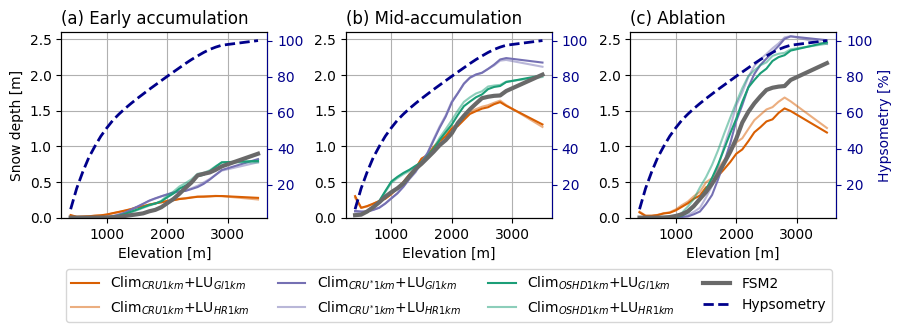

In [54]:
my_pal = {"CRUJRA_FILES_noLapse_OLD": (217/255, 95/255, 2/255), "CRUJRA_FILES_noLapse": (217/255, 95/255, 2/255),
          "CRUJRA_FILES_OLD": (117/255, 112/255, 179/255), "CRUJRA_FILES": (117/255, 112/255, 179/255),
          "OSHD_FILES_OLD": (27/255, 158/255, 119/255), "OSHD_FILES": (27/255, 158/255, 119/255),
          "FSM": "dimgray"}

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 3))
hs_dec_all.plot(ax=ax1, legend=False, color=my_pal)
hs_feb_all.plot(ax=ax2, color=my_pal)
hs_apr_all.plot(ax=ax3, legend=False, color=my_pal)
ax1.grid()
ax2.grid()
ax3.grid()
ax1.set_title('(a) Early accumulation', loc='left')
ax2.set_title('(b) Mid-accumulation', loc='left')
ax3.set_title('(c) Ablation', loc='left')
for patch in ax1.lines[1:-1:2]:
    patch.set_alpha(0.5)
for patch in ax2.lines[1:-1:2]:
    patch.set_alpha(0.5)
for patch in ax3.lines[1:-1:2]:
    patch.set_alpha(0.5)

ax1.lines[-1].set_linewidth(3)
ax2.lines[-1].set_linewidth(3)
ax3.lines[-1].set_linewidth(3)
ax1.set_xlabel('Elevation [m]')
ax2.set_xlabel('Elevation [m]')
ax3.set_xlabel('Elevation [m]')

ax1.set_ylabel('Snow depth [m]')
ax1a = ax1.twinx()
ax1a.plot(dem_hyp_plot, hypsom_cum, color='darkblue', lw=2, ls='--')

ax2a = ax2.twinx()
ls2 = ax2a.plot(dem_hyp_plot, hypsom_cum, color='darkblue', lw=2, ls='--')
labels_new = [r'Clim$_{CRU 1km}$+LU$_{Gl 1km}$', r'Clim$_{CRU 1km}$+LU$_{HR 1km}$',
              r"Clim$_{CRU^{*} 1km}$+LU$_{Gl 1km}$", r"Clim$_{CRU^{*} 1km}$+LU$_{HR 1km}$",
              r"Clim$_{OSHD 1km}$+LU$_{Gl 1km}$", r"Clim$_{OSHD 1km}$+LU$_{HR 1km}$", 'FSM2', 'Hypsometry']
lns = ax2.lines+ls2

ax2.legend(lns, labels_new, bbox_to_anchor=(0.5, -0.6), loc='lower center', ncol=4)

ax3a = ax3.twinx()
ax3a.plot(dem_hyp_plot, hypsom_cum, color='darkblue', lw=2, ls='--')
ax3a.set_ylabel('Hypsometry [%]', color='darkblue')

ax1a.spines["right"].set_edgecolor('darkblue')
ax1a.tick_params(axis='y', colors='darkblue')
ax2a.spines["right"].set_edgecolor('darkblue')
ax2a.tick_params(axis='y', colors='darkblue')
ax3a.spines["right"].set_edgecolor('darkblue')
ax3a.tick_params(axis='y', colors='darkblue')

ax1.set_box_aspect(0.9)
ax2.set_box_aspect(0.9)
ax3.set_box_aspect(0.9)

plt.subplots_adjust(wspace=0.38, hspace=-0.35)

ax1.set_ylim([0, 0.92])
ax2.set_ylim([0, 2.28])
ax3.set_ylim([0, 2.6])

#fig.savefig(base_dir / 'figures_final_revision' / 'f05.png', facecolor='white', transparent=False, bbox_inches='tight', dpi=1000)
fig.savefig(base_dir / 'figures_final_revision' / 'f05.pdf', facecolor='white', transparent=False, bbox_inches='tight')

ax1.set_ylim([0, 2.6])
ax2.set_ylim([0, 2.6])
ax3.set_ylim([0, 2.6])

#fig.savefig(base_dir / 'figures_final_revision' / Path('hypsom_'+str(year_int)+'_sameY.png'), facecolor='white', transparent=False, bbox_inches='tight', dpi=1000)